# Проверка семантического смысла эмбеддеров

## 1. Импорты и настройки

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    confusion_matrix,
)

pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'sans-serif',
})
RANDOM_STATE = 42
print("Импорты выполнены")

✓ Импорты выполнены


## 2. Загрузка данных

In [ ]:
PATH_TCM = "task_competence_mapping.csv"
PATH_MM  = "micromodules_competencies.csv"
PATH_SUB = "user_task_submissions.csv"

tcm  = pd.read_csv(PATH_TCM, sep=';', encoding='utf-8-sig').fillna('')
mm   = pd.read_csv(PATH_MM,  sep=';', encoding='utf-8-sig').fillna('')
subs = pd.read_csv(PATH_SUB, sep=';', encoding='utf-8-sig')

print(f"task_competence_mapping : {len(tcm):>5} строк, {tcm['task_id'].nunique()} уник. задач")
print(f"micromodules_competencies: {len(mm):>5} строк, {mm['node_id'].nunique()} уник. нод")
print(f"user_task_submissions   : {len(subs):>5} строк")

task_competence_mapping :  1613 строк, 550 уник. задач
micromodules_competencies:  1038 строк, 192 уник. нод
user_task_submissions   :  2766 строк


In [ ]:
tcm[['task_id','task_name','task_number','node_name','competence_name']].head(6)

,task_id,task_name,task_number,node_name,competence_name
0,18200de2-8927-49e2-abe0-1182e6e6c82a,№10 - ФИПИ - C7D60A,1,Номер 1. Планиметрия,Планиметрия
1,9a214a3c-5bc1-431b-9adc-f6d26e6f17b0,№11 - ФИПИ - 3CF402,1,Номер 1. Планиметрия,Планиметрия
2,d8ea6c9f-7687-45c2-a7cc-59a6b53c735e,№12 - ФИПИ - 8CB50E,1,Номер 1. Планиметрия,Планиметрия
3,a6c5b2e1-c0bd-4f1f-8786-9d9742ffb51f,№13 - ФИПИ - 79D7B4,1,Номер 1. Планиметрия,Планиметрия
4,93480de3-f5e5-44ff-a2d5-941d0a4ae326,№14 - ФИПИ - 732EBF,1,Номер 1. Планиметрия,Планиметрия
5,63efddf3-65b6-4b5b-b1e8-a58f27c5ee17,№15 - ФИПИ - BC72B9,1,Номер 1. Планиметрия,Планиметрия


In [ ]:
node_counts = tcm.drop_duplicates('task_id').groupby('node_name').size().sort_values(ascending=False)
print(f"Всего уникальных микромодулей: {len(node_counts)}")
print(f"Задач в микромодуле: min={node_counts.min()}, max={node_counts.max()}, медиана={node_counts.median():.0f}")
print()
print("Топ-10 микромодулей по числу задач:")
node_counts.head(10)

Всего уникальных микромодулей: 68
Задач в микромодуле: min=1, max=48, медиана=4

Топ-10 микромодулей по числу задач:


,0
node_name,
Номер 3 ЕГЭ,48
Номер 10 ЕГЭ,45
Номер 11 ЕГЭ,43
Номер 7 ЕГЭ,41
Номер 1. Планиметрия,36
Номер 5 ЕГЭ,34
"7. Вычисление значения производной функции на графике функции в точке хо, определение знака касательной",18
Номер 2 ЕГЭ,15
9. Степенные и иррациональные - Определение экстремумов кубической функции через анализ производной,15


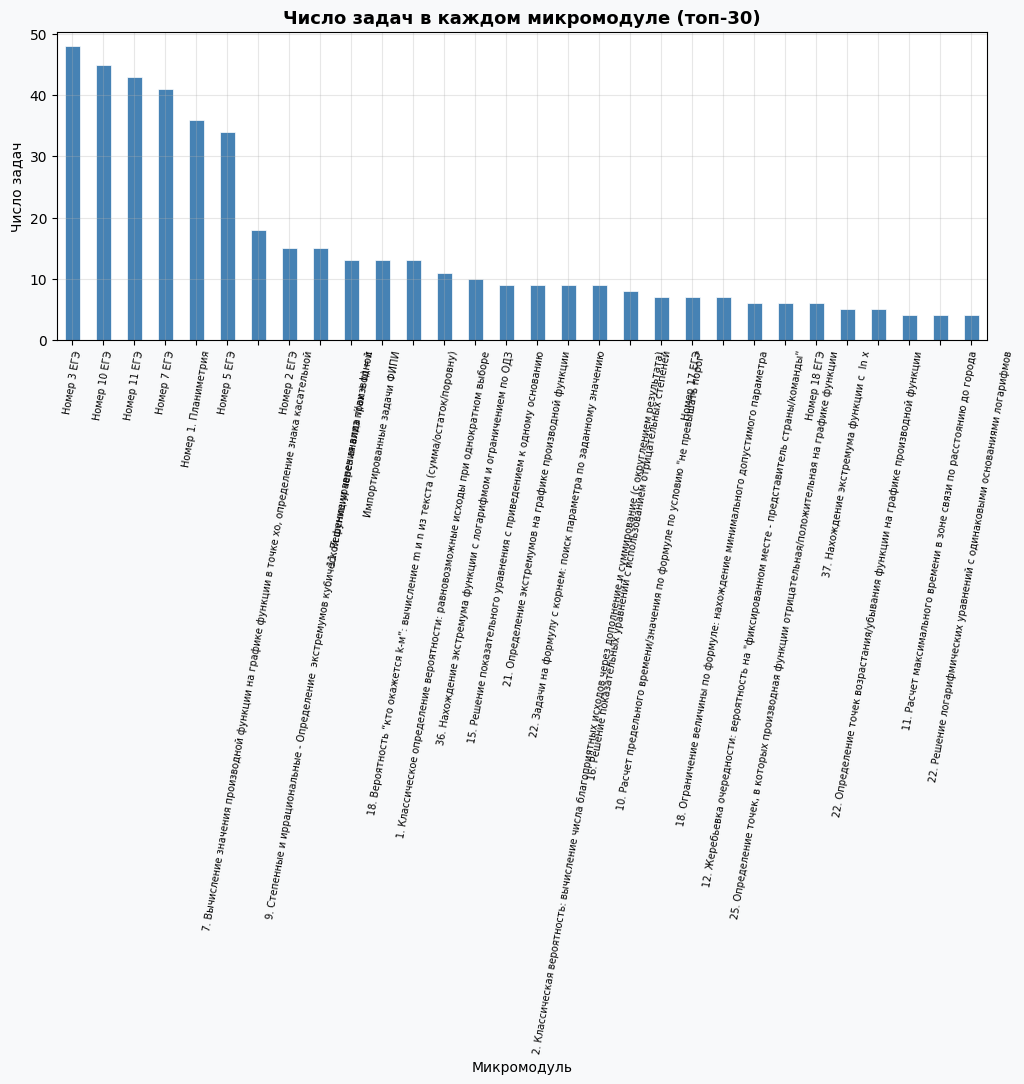

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
node_counts.head(30).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Число задач в каждом микромодуле (топ-30)', fontsize=13, fontweight='bold')
ax.set_xlabel('Микромодуль')
ax.set_ylabel('Число задач')
ax.tick_params(axis='x', rotation=80, labelsize=7)
plt.tight_layout()
plt.show()

## 3. Построение текстовых признаков

In [ ]:
task_df = (
    tcm.groupby('task_id')
    .agg(
        task_number  = ('task_number', 'first'),
        node_name    = ('node_name',   'first'),
        node_id      = ('node_id',     'first'),
        nodes_all    = ('node_name',   lambda x: ' '.join(x.unique())),
        competences  = ('competence_name', lambda x: ' '.join(x.unique())),
    )
    .reset_index()
)

task_df['text'] = task_df['nodes_all'] + ' ' + task_df['competences']

le_node = LabelEncoder()
task_df['node_label'] = le_node.fit_transform(task_df['node_name'])

n_tasks          = len(task_df)
n_true_modules   = task_df['node_name'].nunique()
n_task_numbers   = task_df['task_number'].nunique()

print(f"Задач:              {n_tasks}")
print(f"Истинных кластеров: {n_true_modules}  (уникальных микромодулей)")
print(f"Номеров ЕГЭ:        {n_task_numbers}")
print()
print("Пример текста задачи:")
print(task_df['text'].iloc[5])

Задач:              550
Истинных кластеров: 68  (уникальных микромодулей)
Номеров ЕГЭ:        19

Пример текста задачи:
Номер 11 ЕГЭ Графики функций


## 4. Embedder

In [ ]:
EMBEDDERS = {
    "TF-IDF unigrams":     TfidfVectorizer(ngram_range=(1,1), min_df=1, max_features=3000, sublinear_tf=True),
    "TF-IDF bigrams":      TfidfVectorizer(ngram_range=(1,2), min_df=1, max_features=5000, sublinear_tf=True),
    "Char n-grams (3-5)":  TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=1, max_features=5000, sublinear_tf=True),
    "BoW bigrams":         CountVectorizer(ngram_range=(1,2), min_df=1, max_features=5000),
}

def embed(vectorizer, texts, n_svd=50):
    X_raw = vectorizer.fit_transform(texts)
    n_comp = min(n_svd, X_raw.shape[1] - 1, len(texts) - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
    X = normalize(svd.fit_transform(normalize(X_raw)))
    var = svd.explained_variance_ratio_.sum()
    print(f"  Vectorizer: {X_raw.shape[1]} признаков → SVD({n_comp}), объясн. дисперсия = {var:.3f}")
    return X, svd

def purity_score(y_true, y_pred):
    n = len(y_true)
    clusters = np.unique(y_pred)
    return sum(Counter(y_true[y_pred == c]).most_common(1)[0][1] for c in clusters) / n

def evaluate(X, y_true, n_clusters, name=""):
    km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    y_pred = km.fit_predict(X)
    sil = silhouette_score(X, y_pred, metric='cosine', sample_size=min(500, len(X)))
    return {
        'embedder':     name,
        'ARI':          adjusted_rand_score(y_true, y_pred),
        'NMI':          normalized_mutual_info_score(y_true, y_pred),
        'V-measure':    v_measure_score(y_true, y_pred),
        'Homogeneity':  homogeneity_score(y_true, y_pred),
        'Completeness': completeness_score(y_true, y_pred),
        'Purity':       purity_score(y_true, y_pred),
        'Silhouette':   sil,
        'y_pred':       y_pred,
    }

print("Параметры эмбеддинга:")

Параметры эмбеддинга:


In [ ]:
texts = task_df['text'].tolist()
y     = task_df['node_label'].values

embedded = {}
print("Строим эмбеддинги:")
for name, vec in EMBEDDERS.items():
    print(f"\n[{name}]")
    X, svd = embed(vec, texts, n_svd=50)
    embedded[name] = X

print("Готово")

Строим эмбеддинги:

[TF-IDF unigrams]
  Vectorizer: 583 признаков → SVD(50), объясн. дисперсия = 0.983

[TF-IDF bigrams]
  Vectorizer: 1685 признаков → SVD(50), объясн. дисперсия = 0.976

[Char n-grams (3-5)]
  Vectorizer: 5000 признаков → SVD(50), объясн. дисперсия = 0.991

[BoW bigrams]
  Vectorizer: 1685 признаков → SVD(50), объясн. дисперсия = 0.988

✓ Готово


## 5. Метрики качества кластеризации

In [ ]:
print(f"Кластеризуем с k = {n_true_modules} (= числу микромодулей в данных)\n")

results = []
for name, X in embedded.items():
    metrics = evaluate(X, y, n_clusters=n_true_modules, name=name)
    results.append(metrics)
    print(f"[{name}]")
    for m in ['ARI','NMI','V-measure','Homogeneity','Completeness','Purity','Silhouette']:
        bar = '█' * int(metrics[m] * 20) + '░' * (20 - int(metrics[m]*20))
        print(f"  {m:14s} {bar} {metrics[m]:.4f}")
    print()

Кластеризуем с k = 68 (= числу микромодулей в данных)

[TF-IDF unigrams]
  ARI            ███████████████████░ 0.9994
  NMI            ███████████████████░ 0.9987
  V-measure      ███████████████████░ 0.9987
  Homogeneity    ███████████████████░ 0.9986
  Completeness   ███████████████████░ 0.9989
  Purity         ███████████████████░ 0.9964
  Silhouette     ███████████████████░ 0.9754

[TF-IDF bigrams]
  ARI            ███████████████████░ 0.9969
  NMI            ███████████████████░ 0.9961
  V-measure      ███████████████████░ 0.9961
  Homogeneity    ███████████████████░ 0.9958
  Completeness   ███████████████████░ 0.9964
  Purity         ███████████████████░ 0.9927
  Silhouette     ███████████████████░ 0.9702

[Char n-grams (3-5)]
  ARI            ███████████████████░ 0.9994
  NMI            ███████████████████░ 0.9987
  V-measure      ███████████████████░ 0.9987
  Homogeneity    ███████████████████░ 0.9986
  Completeness   ███████████████████░ 0.9989
  Purity         ███████████████

## 6. Сравнение эмбеддеров — итоговая таблица

In [ ]:
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('y_pred',)}
    for r in results
]).set_index('embedder').round(4)

styled = metrics_df.style\
    .background_gradient(cmap='RdYlGn', axis=0)\
    .format('{:.4f}')\
    .set_caption('Качество кластеризации по эмбеддерам (k = число микромодулей)')

print("Лучший эмбеддер по ARI:", metrics_df['ARI'].idxmax())
print("Лучший эмбеддер по NMI:", metrics_df['NMI'].idxmax())
styled

Лучший эмбеддер по ARI: TF-IDF unigrams
Лучший эмбеддер по NMI: TF-IDF unigrams


,ARI,NMI,V-measure,Homogeneity,Completeness,Purity,Silhouette
embedder,,,,,,,
TF-IDF unigrams,0.9994,0.9987,0.9987,0.9986,0.9989,0.9964,0.9754
TF-IDF bigrams,0.9969,0.9961,0.9961,0.9958,0.9964,0.9927,0.9702
Char n-grams (3-5),0.9994,0.9987,0.9987,0.9986,0.9989,0.9964,0.9738
BoW bigrams,0.9952,0.9942,0.9942,0.9945,0.9938,0.9909,0.9725


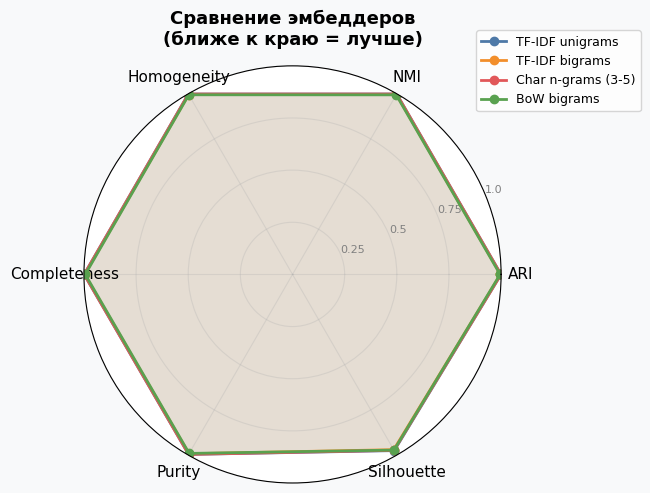

In [ ]:
metric_names = ['ARI','NMI','Homogeneity','Completeness','Purity','Silhouette']
N = len(metric_names)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
colors = ['#4e79a7','#f28e2b','#e15759','#59a14f']

for (name, row), color in zip(metrics_df[metric_names].iterrows(), colors):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=8, color='grey')
ax.set_title('Сравнение эмбеддеров\n(ближе к краю = лучше)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

## 7. Визуализация в 2D — t-SNE

In [ ]:
best_name  = metrics_df['ARI'].idxmax()
X_best     = embedded[best_name]
best_preds = next(r['y_pred'] for r in results if r['embedder'] == best_name)

print(f"Используем: [{best_name}]")
print("Запускаем t-SNE (может занять ~30с)...")

tsne = TSNE(n_components=2, perplexity=30, max_iter=1500,
            random_state=RANDOM_STATE, learning_rate='auto',
            init='pca', metric='cosine')
coords = tsne.fit_transform(X_best)
task_df['tsne_x'] = coords[:, 0]
task_df['tsne_y'] = coords[:, 1]
print("Готово")

Используем: [TF-IDF unigrams]
Запускаем t-SNE (может занять ~30с)...
✓ Готово


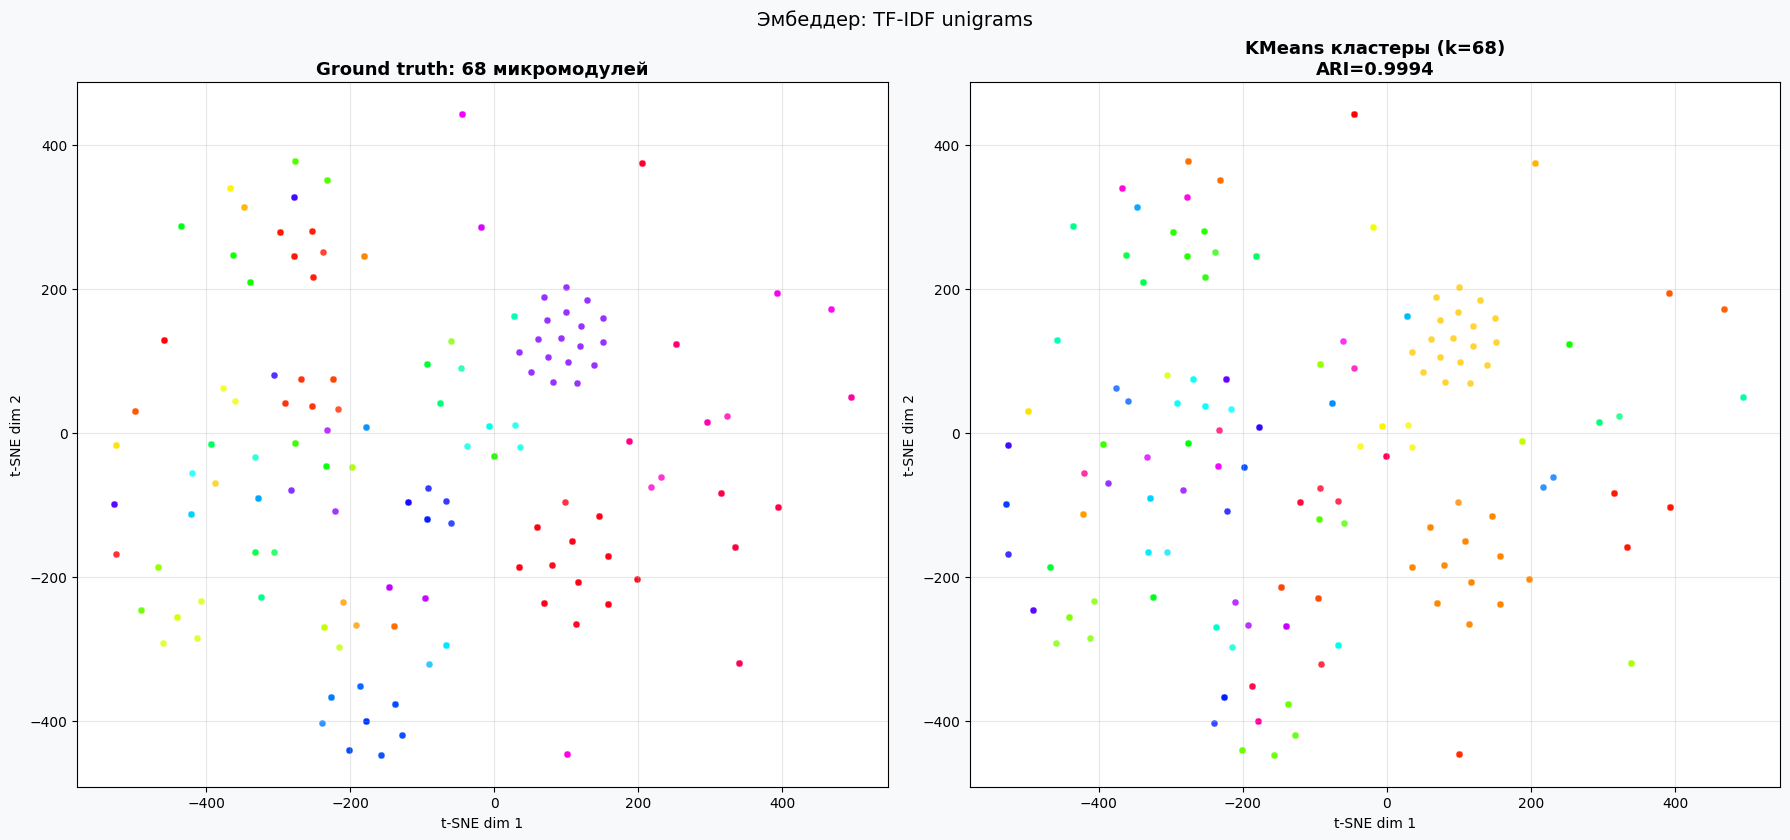

Идеальное ARI ≈ 1 означает: кластеры (правый) ≅ микромодули (левый)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

cmap = plt.cm.get_cmap('hsv', n_true_modules)
node_colors = {label: cmap(i / n_true_modules)
               for i, label in enumerate(sorted(task_df['node_label'].unique()))}

ax = axes[0]
for node_lbl, group in task_df.groupby('node_label'):
    c = node_colors[node_lbl]
    ax.scatter(group['tsne_x'], group['tsne_y'],
               color=c, s=25, alpha=0.8, edgecolors='white', linewidths=0.3)
ax.set_title(f'Ground truth: {n_true_modules} микромодулей', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.set_aspect('equal')

ax = axes[1]
cmap2 = plt.cm.get_cmap('hsv', n_true_modules)
for c_lbl in sorted(np.unique(best_preds)):
    mask = best_preds == c_lbl
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=cmap2(c_lbl / n_true_modules),
               s=25, alpha=0.8, edgecolors='white', linewidths=0.3)
ax.set_title(f'KMeans кластеры (k={n_true_modules})\nARI={metrics_df.loc[best_name,"ARI"]:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.set_aspect('equal')

plt.suptitle(f'Эмбеддер: {best_name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Идеальное ARI ≈ 1 означает: кластеры (правый) ≅ микромодули (левый)")

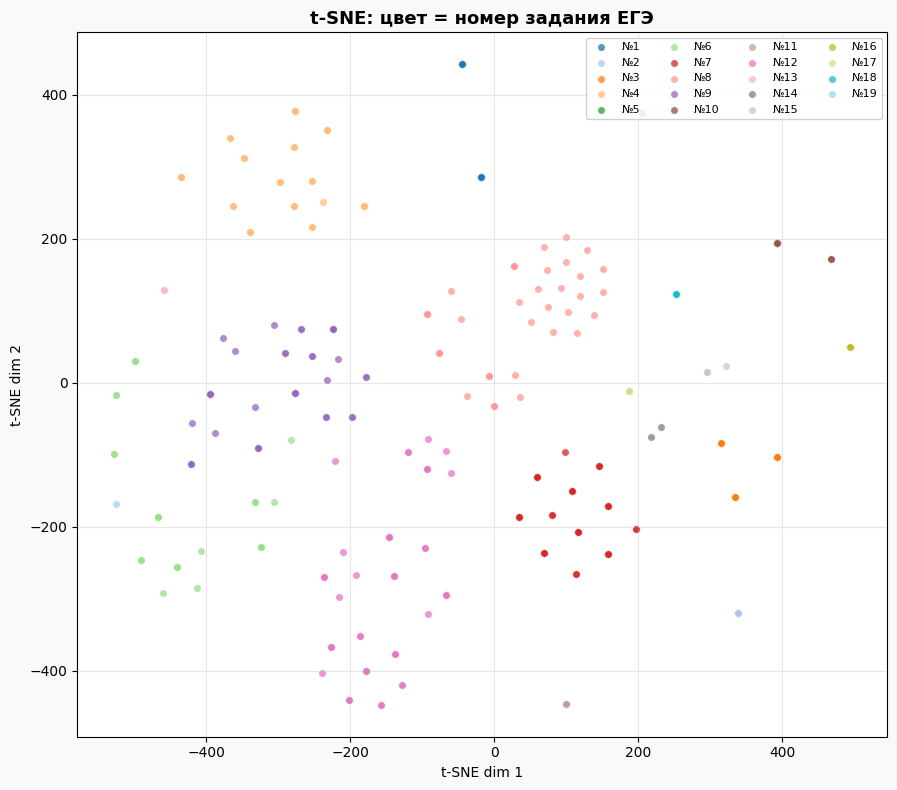

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
cmap3 = plt.cm.get_cmap('tab20', n_task_numbers)
task_nums = sorted(task_df['task_number'].unique())

for i, tn in enumerate(task_nums):
    group = task_df[task_df['task_number'] == tn]
    ax.scatter(group['tsne_x'], group['tsne_y'],
               color=cmap3(i / n_task_numbers),
               s=28, alpha=0.75, edgecolors='white', linewidths=0.3, label=f'№{tn}')

ax.set_title('t-SNE: цвет = номер задания ЕГЭ', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.legend(ncol=4, fontsize=8, loc='upper right', framealpha=0.9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 8. Чувствительность к числу кластеров k

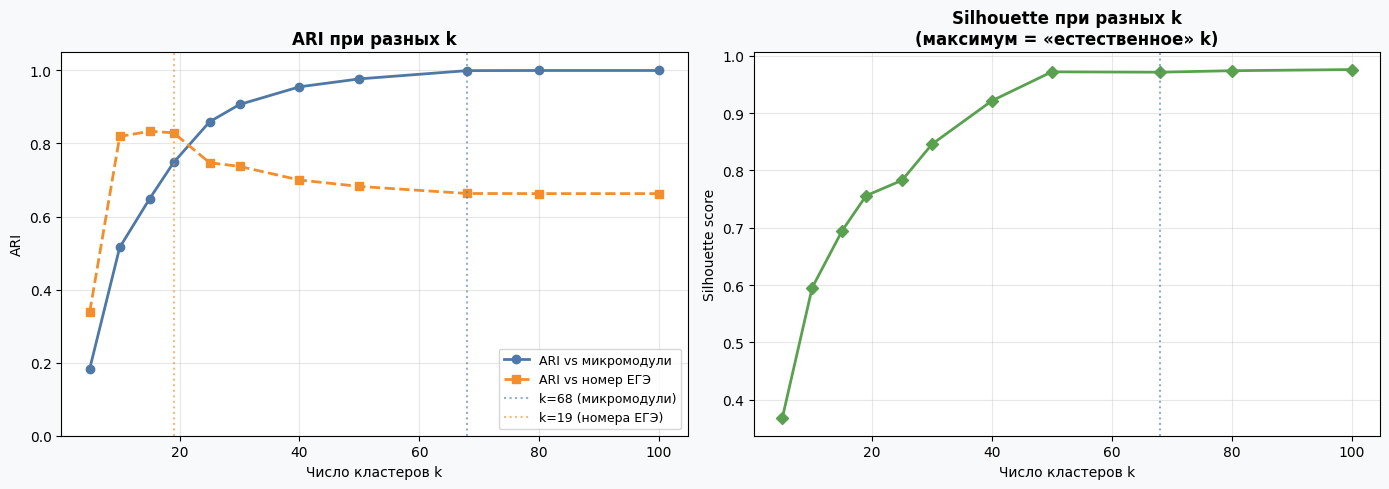

Вывод: ARI по микромодулям достигает максимума при k = 80
ARI по номеру ЕГЭ максимален при k = 15


In [ ]:
k_range = [5, 10, 15, 19, 25, 30, 40, 50, 68, 80, 100]
k_results = {'k': k_range, 'ARI_node': [], 'ARI_tasknum': [], 'Silhouette': []}

X_best = embedded[best_name]
le_num = LabelEncoder()
y_num  = le_num.fit_transform(task_df['task_number'].astype(str))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    preds = km.fit_predict(X_best)
    k_results['ARI_node'].append(adjusted_rand_score(y, preds))
    k_results['ARI_tasknum'].append(adjusted_rand_score(y_num, preds))
    k_results['Silhouette'].append(silhouette_score(X_best, preds, metric='cosine', sample_size=500))

k_df = pd.DataFrame(k_results).set_index('k')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(k_df.index, k_df['ARI_node'],    'o-', color='#4e79a7', lw=2, label='ARI vs микромодули')
ax.plot(k_df.index, k_df['ARI_tasknum'], 's--',color='#f28e2b', lw=2, label='ARI vs номер ЕГЭ')
ax.axvline(x=n_true_modules,  color='#4e79a7', ls=':', alpha=0.6, label=f'k={n_true_modules} (микромодули)')
ax.axvline(x=n_task_numbers,  color='#f28e2b', ls=':', alpha=0.6, label=f'k={n_task_numbers} (номера ЕГЭ)')
ax.set_xlabel('Число кластеров k'); ax.set_ylabel('ARI')
ax.set_title('ARI при разных k', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

ax = axes[1]
ax.plot(k_df.index, k_df['Silhouette'], 'D-', color='#59a14f', lw=2)
ax.axvline(x=n_true_modules, color='#4e79a7', ls=':', alpha=0.6)
ax.set_xlabel('Число кластеров k'); ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette при разных k\n(максимум = «естественное» k)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Вывод: ARI по микромодулям достигает максимума при k =", k_df['ARI_node'].idxmax())
print("ARI по номеру ЕГЭ максимален при k =", k_df['ARI_tasknum'].idxmax())

## 9. Анализ ошибок

In [ ]:
km_best = KMeans(n_clusters=n_true_modules, random_state=RANDOM_STATE, n_init=10)
task_df['cluster'] = km_best.fit_predict(embedded[best_name])

cluster_to_node = (
    task_df.groupby('cluster')['node_name']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
task_df['predicted_node'] = task_df['cluster'].map(cluster_to_node)
task_df['correct'] = task_df['node_name'] == task_df['predicted_node']

n_errors = (~task_df['correct']).sum()
print(f"Всего задач: {n_tasks}")
print(f"Правильно размещены: {task_df['correct'].sum()} ({task_df['correct'].mean()*100:.1f}%)")
print(f"Ошибочно размещены:  {n_errors} ({n_errors/n_tasks*100:.1f}%)")
print()
if n_errors > 0:
    print("Ошибочно размещённые задачи:")
    err_cols = ['task_number','node_name','predicted_node','cluster']
    display(task_df[~task_df['correct']][err_cols].reset_index(drop=True))
else:
    print("Все задачи размещены в правильный кластер!")

Всего задач: 550
Правильно размещены: 548 (99.6%)
Ошибочно размещены:  2 (0.4%)

Ошибочно размещённые задачи:


,task_number,node_name,predicted_node,cluster
0,12,43. Нахождение наибольшего/наименьшего значения функции с sin x и дробным коэффициент...,42. Нахождение наибольшего/наименьшего значения функции с cos x и дробным коэффициент...,66
1,12,43. Нахождение наибольшего/наименьшего значения функции с sin x и дробным коэффициент...,42. Нахождение наибольшего/наименьшего значения функции с cos x и дробным коэффициент...,66


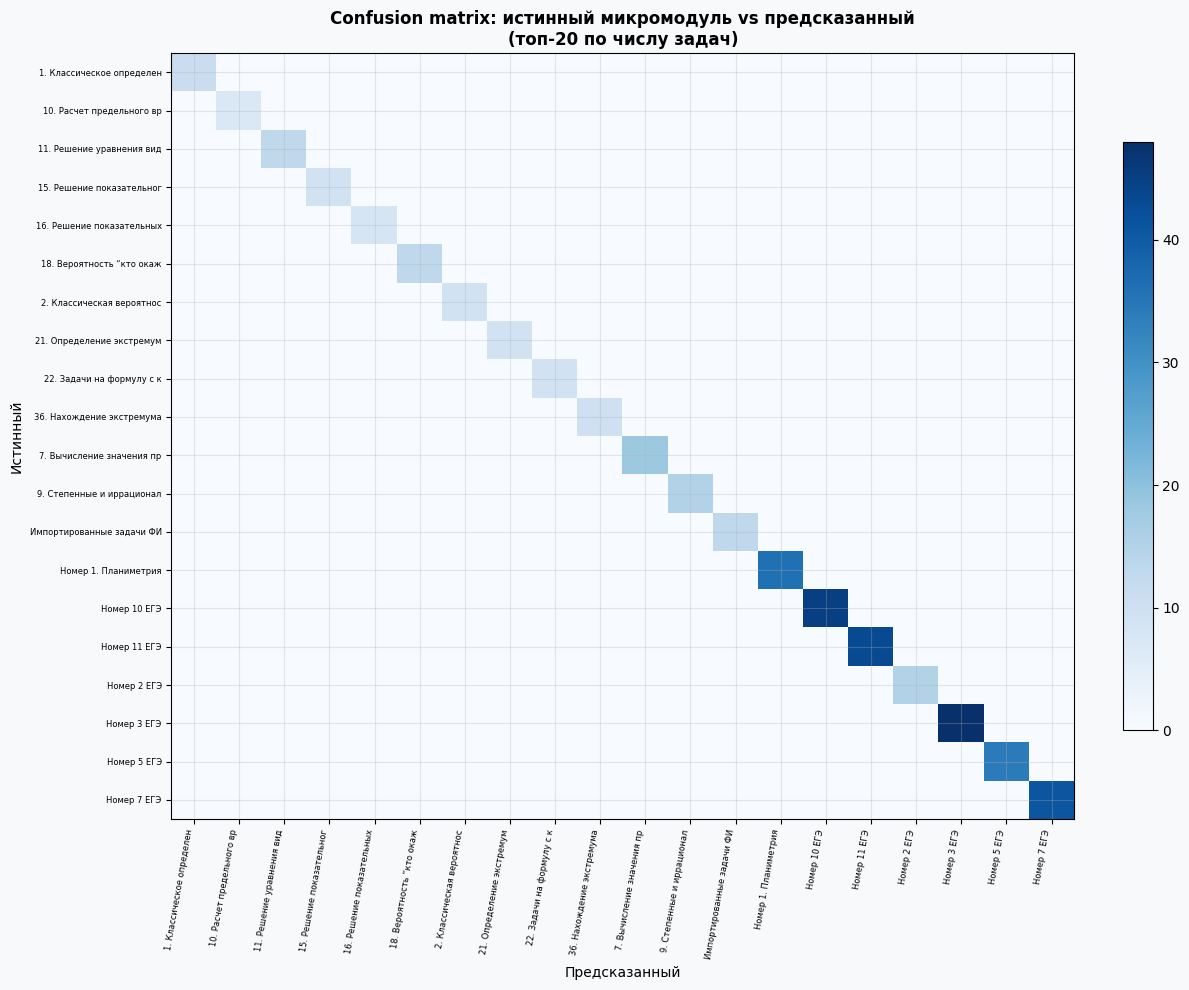

In [ ]:
top_nodes = node_counts.head(20).index.tolist()
mask = task_df['node_name'].isin(top_nodes)
sub = task_df[mask]

all_nodes = sorted(sub['node_name'].unique())
le20 = LabelEncoder().fit(all_nodes)

try:
    y20_true = le20.transform(sub['node_name'])
    pred_mapped = sub['predicted_node'].apply(lambda x: x if x in all_nodes else sub['node_name'].iloc[0])
    y20_pred = le20.transform(pred_mapped)
    cm = confusion_matrix(y20_true, y20_pred)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ticks = range(len(all_nodes))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    short = [n[:25] for n in all_nodes]
    ax.set_xticklabels(short, rotation=80, fontsize=6, ha='right')
    ax.set_yticklabels(short, fontsize=6)
    ax.set_title('Confusion matrix: истинный микромодуль vs предсказанный\n(топ-20 по числу задач)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Предсказанный'); ax.set_ylabel('Истинный')
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Confusion matrix: {e}")

## 10. Иерархическая кластеризация

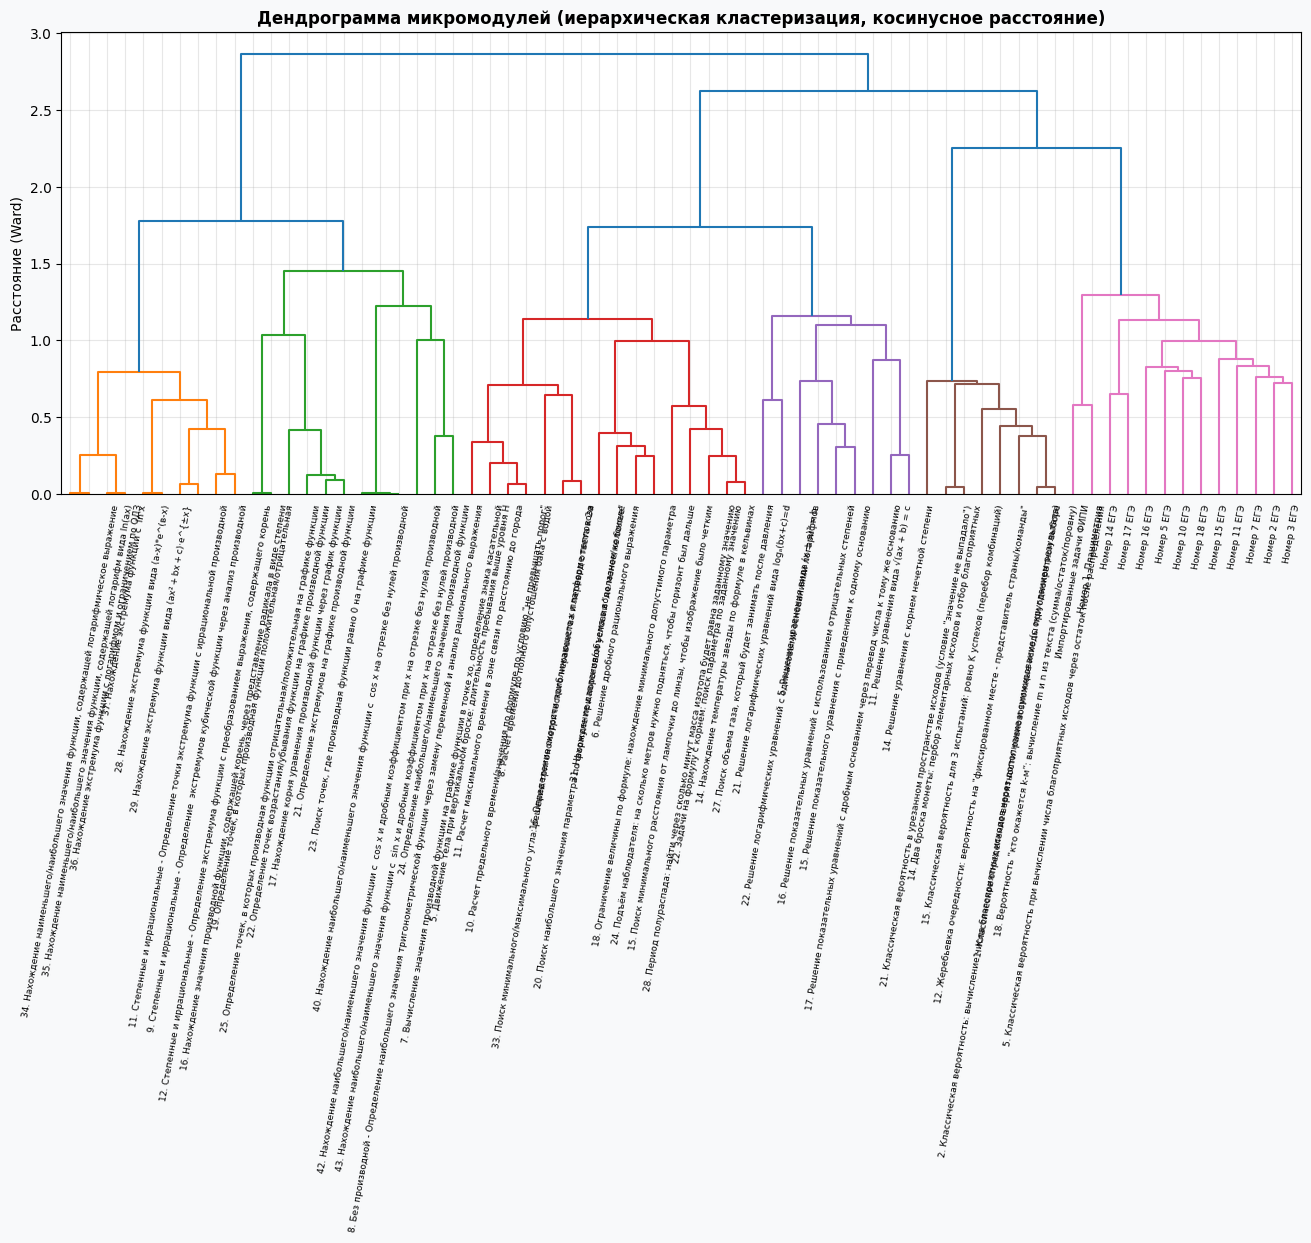

Ветки дендрограммы = семантически близкие группы микромодулей


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

X_best = embedded[best_name]
module_centers = (
    pd.DataFrame(X_best, index=task_df['node_name'])
    .groupby(level=0)
    .mean()
)

Z = linkage(pdist(module_centers.values, metric='cosine'), method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z,
    labels=module_centers.index.tolist(),
    ax=ax,
    leaf_rotation=80,
    leaf_font_size=6.5,
    color_threshold=0.6 * max(Z[:, 2]),
)
ax.set_title('Дендрограмма микромодулей (иерархическая кластеризация, косинусное расстояние)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Расстояние (Ward)')
plt.tight_layout()
plt.show()
print("Ветки дендрограммы = семантически близкие группы микромодулей")

## 11. Проверка ближайших соседей

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

X_best = embedded[best_name]
sim_matrix = cosine_similarity(X_best)

def show_neighbors(task_idx, k=5):
    task   = task_df.iloc[task_idx]
    sims   = sim_matrix[task_idx]
    top_k  = np.argsort(sims)[::-1][1:k+1]

    print(f"🔍 Запрос  [№{task['task_number']}] {task['node_name'][:70]}")
    print(f"   Компетенции: {task['competences'][:100]}")
    print()
    same_count = 0
    for rank, j in enumerate(top_k, 1):
        neighbor = task_df.iloc[j]
        match    = '✓' if neighbor['node_name'] == task['node_name'] else '✗'
        if neighbor['node_name'] == task['node_name']:
            same_count += 1
        print(f"  {match} #{rank} sim={sims[j]:.3f}  [№{neighbor['task_number']}] {neighbor['node_name'][:65]}")
    print(f"\n  Совпадений с микромодулем: {same_count}/{k}")
    return same_count

print("="*75)
for idx in [0, 50, 200]:
    show_neighbors(idx)
    print("="*75)

🔍 Запрос  [№1] Импортированные задачи ФИПИ
   Компетенции: Планиметрия

  ✓ #1 sim=1.000  [№1] Импортированные задачи ФИПИ
  ✓ #2 sim=1.000  [№1] Импортированные задачи ФИПИ
  ✓ #3 sim=1.000  [№1] Импортированные задачи ФИПИ
  ✓ #4 sim=1.000  [№1] Импортированные задачи ФИПИ
  ✓ #5 sim=1.000  [№1] Импортированные задачи ФИПИ

  Совпадений с микромодулем: 5/5
🔍 Запрос  [№1] Номер 1. Планиметрия
   Компетенции: Планиметрия

  ✓ #1 sim=1.000  [№1] Номер 1. Планиметрия
  ✓ #2 sim=1.000  [№1] Номер 1. Планиметрия
  ✓ #3 sim=1.000  [№1] Номер 1. Планиметрия
  ✓ #4 sim=1.000  [№1] Номер 1. Планиметрия
  ✓ #5 sim=1.000  [№1] Номер 1. Планиметрия

  Совпадений с микромодулем: 5/5
🔍 Запрос  [№16] Номер 16 ЕГЭ
   Компетенции: Экономические задачи

  ✓ #1 sim=1.000  [№16] Номер 16 ЕГЭ
  ✓ #2 sim=1.000  [№16] Номер 16 ЕГЭ
  ✗ #3 sim=0.225  [№10] Номер 10 ЕГЭ
  ✗ #4 sim=0.225  [№10] Номер 10 ЕГЭ
  ✗ #5 sim=0.225  [№10] Номер 10 ЕГЭ

  Совпадений с микромодулем: 2/5


Точность ближайших соседей (доля из топ-5 того же микромодуля):
  Средняя: 4.425
  Медиана: 5
  Задач с 5/5 совпадений: 438 (80%)
  Задач с 0   совпадений: 11 (2%)


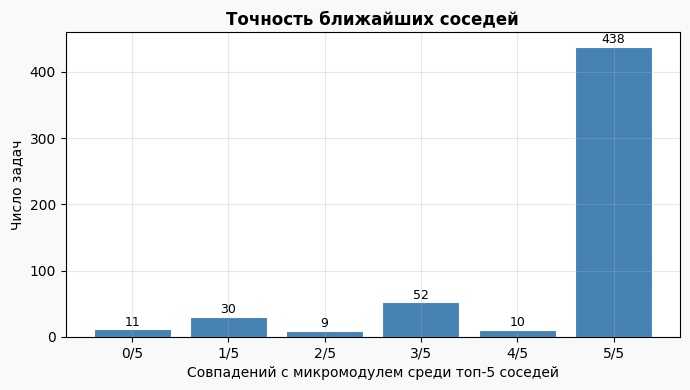

In [ ]:
hits = []
for i in range(len(task_df)):
    sims   = sim_matrix[i]
    top5   = np.argsort(sims)[::-1][1:6]
    node_i = task_df.iloc[i]['node_name']
    same   = sum(1 for j in top5 if task_df.iloc[j]['node_name'] == node_i)
    hits.append(same)

hits = np.array(hits)
print("Точность ближайших соседей (доля из топ-5 того же микромодуля):")
print(f"  Средняя: {hits.mean():.3f}")
print(f"  Медиана: {np.median(hits):.0f}")
print(f"  Задач с 5/5 совпадений: {(hits==5).sum()} ({(hits==5).mean()*100:.0f}%)")
print(f"  Задач с 0   совпадений: {(hits==0).sum()} ({(hits==0).mean()*100:.0f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
counts = [np.sum(hits==h) for h in range(6)]
bars = ax.bar(range(6), counts, color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xticks(range(6))
ax.set_xticklabels([f'{h}/5' for h in range(6)])
ax.set_xlabel('Совпадений с микромодулем среди топ-5 соседей')
ax.set_ylabel('Число задач')
ax.set_title('Точность ближайших соседей', fontsize=12, fontweight='bold')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()